In [1]:
# importação das bibliotecas necessárias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import time

# XGBoost
from xgboost import XGBClassifier

# bibliotecas do scikit-learn para métricas
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)



In [2]:
# definindo caminhos
pasta_treino_teste = '../dados/dados_processados/treino_teste/'
pasta_modelos = '../modelos/'

print("Carregando conjuntos de treino e teste\n")

# carregando atributos das 3 versões
X_train_orig = pd.read_csv(os.path.join(pasta_treino_teste, 'X_train_original.csv'))
X_test_orig = pd.read_csv(os.path.join(pasta_treino_teste, 'X_test_original.csv'))

X_train_pca = pd.read_csv(os.path.join(pasta_treino_teste, 'X_train_pca.csv'))
X_test_pca = pd.read_csv(os.path.join(pasta_treino_teste, 'X_test_pca.csv'))

X_train_lda = pd.read_csv(os.path.join(pasta_treino_teste, 'X_train_lda.csv'))
X_test_lda = pd.read_csv(os.path.join(pasta_treino_teste, 'X_test_lda.csv'))

# carregando rótulos 
y_train = pd.read_csv(os.path.join(pasta_treino_teste, 'y_train.csv')).iloc[:, 0]
y_test = pd.read_csv(os.path.join(pasta_treino_teste, 'y_test.csv')).iloc[:, 0]

# carregando codificador
codificador = joblib.load(os.path.join(pasta_modelos, 'codificador_rotulos_amostrado.pkl'))

print(f" Treino: {len(y_train):,} registros | Teste: {len(y_test):,} registros")
print(f" Classes: {list(codificador.classes_)}")

print(f"\nFormatos:")
print(f"{'Versão':<12} {'formato de treino':<15} {'formato do teste':<15}")
print("=" * 45)
print(f"{'Original':<12} {str(X_train_orig.shape):<15} {str(X_test_orig.shape):<15}")
print(f"{'PCA':<12} {str(X_train_pca.shape):<15} {str(X_test_pca.shape):<15}")
print(f"{'LDA':<12} {str(X_train_lda.shape):<15} {str(X_test_lda.shape):<15}")


Carregando conjuntos de treino e teste

 Treino: 7,000 registros | Teste: 3,000 registros
 Classes: ['BENIGN', 'DDoS', 'DoS Hulk', 'PortScan']

Formatos:
Versão       formato de treino formato do teste
Original     (7000, 78)      (3000, 78)     
PCA          (7000, 15)      (3000, 15)     
LDA          (7000, 3)       (3000, 3)      


C:\Users\William\AppData\Roaming\Python\Python314\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
# configuração dos hiperparâmetros do XGBoost
# valores escolhidos com base em boas práticas para classificação multiclasse

config_xgb = {
    'n_estimators': 100,           # número de árvores 
    'max_depth': 6,                # profundidade máxima de cada árvore em nós
    'learning_rate': 0.1,          # taxa de aprendizado
    'objective': 'multi:softmax',  # classificação multiclasse
    'num_class': 4,                # numero de classes que estamos analisando
    'subsample': 0.8,              # 80% das amostras por árvore
    'colsample_bytree': 0.8,       # 80% dos atributos por árvore
    'random_state': 1,             # semente usada em todo projeto
    'n_jobs': -1,                  # usa todos os cores do pc
    'eval_metric': 'mlogloss',     # métrica multiclasse
    'verbosity': 0                 # sem output durante treinamento por enquanto
}

print("Configuração do XGBoost:")
print("=" * 55)
for param, valor in config_xgb.items():
    print(f"   {param:<22} = {valor}")
print("=" * 55)


Configuração do XGBoost:
   n_estimators           = 100
   max_depth              = 6
   learning_rate          = 0.1
   objective              = multi:softmax
   num_class              = 4
   subsample              = 0.8
   colsample_bytree       = 0.8
   random_state           = 1
   n_jobs                 = -1
   eval_metric            = mlogloss
   verbosity              = 0


In [4]:
# função reutilizável para treinar e avaliar um XGBoost
# estrutura igual a etapa 6.1 feita para o random forest

def treinar_e_avaliar_xgb(X_train, X_test, y_train, y_test, nome_versao, config):
    """
    treina um XGBoost e retorna as métricas e o  modelo
    
    parâmetros:
    -----------
    X_train, X_test : conjuntos de atributos
    y_train, y_test : conjuntos de rótulos
    nome_versao     : str, nome da versão (Original, PCA, LDA)
    config          : dict, hiperparâmetros do modelo
    
    Retorna:
    --------
    dict com modelo, predições, métricas e tempos
    """
    print(f"\n{'='*60}")
    print(f"Treinando XGBoost — Versão {nome_versao}")
    print(f"{'='*60}")
    print(f"   Atributos: {X_train.shape[1]}")
    print(f"   Treino:    {X_train.shape[0]:,} registros")
    print(f"   Teste:     {X_test.shape[0]:,} registros")
    
    # criando o modelo
    modelo = XGBClassifier(**config)
    
    # treinamento para medir o tempo de execução
    print(f"\n Treinando modelo")
    inicio_treino = time.time()
    modelo.fit(X_train, y_train)
    tempo_treino = time.time() - inicio_treino
    print(f" Treinamento concluído em {tempo_treino:.2f} segundos")
    
    # predição para medir o tempo de execução
    print(f"  Realizando predições...")
    inicio_pred = time.time()
    y_pred = modelo.predict(X_test)
    tempo_pred = time.time() - inicio_pred
    print(f" Predição concluída em {tempo_pred:.4f} segundos")
    
    # calculando métricas
    acuracia = accuracy_score(y_test, y_pred)
    precisao = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    print(f"\n Métricas:")
    print(f"    Acurácia:  {acuracia*100:.2f}%")
    print(f"    Precisão:  {precisao*100:.2f}%")
    print(f"    Recall:    {recall*100:.2f}%")
    print(f"    F1-Score:  {f1*100:.2f}%")
    
    return {
        'nome': nome_versao,
        'modelo': modelo,
        'y_pred': y_pred,
        'tempo_treino': tempo_treino,
        'tempo_pred': tempo_pred,
        'acuracia': acuracia,
        'precisao': precisao,
        'recall': recall,
        'f1': f1
    }



In [6]:
# treinando o XGBoost nas 3 versões dos dados
print("Iniciando treinamento dos 3 modelos XGBoost\n")

resultados = {}

# versão 1 com dados originais
resultados['Original'] = treinar_e_avaliar_xgb(
    X_train_orig, X_test_orig, y_train, y_test,
    nome_versao='Original',
    config=config_xgb
)

# versão 2 com dados com PCA
resultados['PCA'] = treinar_e_avaliar_xgb(
    X_train_pca, X_test_pca, y_train, y_test,
    nome_versao='PCA',
    config=config_xgb
)

# versão 3 com dados com LDA
resultados['LDA'] = treinar_e_avaliar_xgb(
    X_train_lda, X_test_lda, y_train, y_test,
    nome_versao='LDA',
    config=config_xgb
)

print(f"\n{'='*60}")
print(f"Todos os modelos foram treinados com sucesso")
print(f"{'='*60}")


Iniciando treinamento dos 3 modelos XGBoost


Treinando XGBoost — Versão Original
   Atributos: 78
   Treino:    7,000 registros
   Teste:     3,000 registros

 Treinando modelo
 Treinamento concluído em 0.94 segundos
  Realizando predições...
 Predição concluída em 0.0128 segundos

 Métricas:
    Acurácia:  99.77%
    Precisão:  99.77%
    Recall:    99.77%
    F1-Score:  99.77%

Treinando XGBoost — Versão PCA
   Atributos: 15
   Treino:    7,000 registros
   Teste:     3,000 registros

 Treinando modelo
 Treinamento concluído em 0.49 segundos
  Realizando predições...
 Predição concluída em 0.0067 segundos

 Métricas:
    Acurácia:  98.87%
    Precisão:  98.87%
    Recall:    98.87%
    F1-Score:  98.87%

Treinando XGBoost — Versão LDA
   Atributos: 3
   Treino:    7,000 registros
   Teste:     3,000 registros

 Treinando modelo
 Treinamento concluído em 0.24 segundos
  Realizando predições...
 Predição concluída em 0.0060 segundos

 Métricas:
    Acurácia:  98.77%
    Precisão:  98.

In [7]:
# criando tabela comparativa com todas as métricas
print("TABELA COMPARATIVA — XGBoost nas 3 versões\n")

df_comparacao = pd.DataFrame({
    'Versão': [r['nome'] for r in resultados.values()],
    'Atributos': [
        X_train_orig.shape[1],
        X_train_pca.shape[1],
        X_train_lda.shape[1]
    ],
    'Acurácia (%)': [r['acuracia']*100 for r in resultados.values()],
    'Precisão (%)': [r['precisao']*100 for r in resultados.values()],
    'Recall (%)': [r['recall']*100 for r in resultados.values()],
    'F1-Score (%)': [r['f1']*100 for r in resultados.values()],
    'Tempo Treino (s)': [r['tempo_treino'] for r in resultados.values()],
    'Tempo Pred. (s)': [r['tempo_pred'] for r in resultados.values()]
})

# formatando para exibição
df_comparacao_formatado = df_comparacao.copy()
for col in ['Acurácia (%)', 'Precisão (%)', 'Recall (%)', 'F1-Score (%)']:
    df_comparacao_formatado[col] = df_comparacao_formatado[col].apply(lambda x: f"{x:.2f}")
df_comparacao_formatado['Tempo Treino (s)'] = df_comparacao_formatado['Tempo Treino (s)'].apply(lambda x: f"{x:.2f}")
df_comparacao_formatado['Tempo Pred. (s)'] = df_comparacao_formatado['Tempo Pred. (s)'].apply(lambda x: f"{x:.4f}")

print(df_comparacao_formatado.to_string(index=False))

# identificando o melhor modelo
melhor_versao = df_comparacao.loc[df_comparacao['F1-Score (%)'].idxmax(), 'Versão']
print(f"\nMelhor versão (por F1-Score): {melhor_versao}")


TABELA COMPARATIVA — XGBoost nas 3 versões

  Versão  Atributos Acurácia (%) Precisão (%) Recall (%) F1-Score (%) Tempo Treino (s) Tempo Pred. (s)
Original         78        99.77        99.77      99.77        99.77             0.94          0.0128
     PCA         15        98.87        98.87      98.87        98.87             0.49          0.0067
     LDA          3        98.77        98.77      98.77        98.77             0.24          0.0060

Melhor versão (por F1-Score): Original


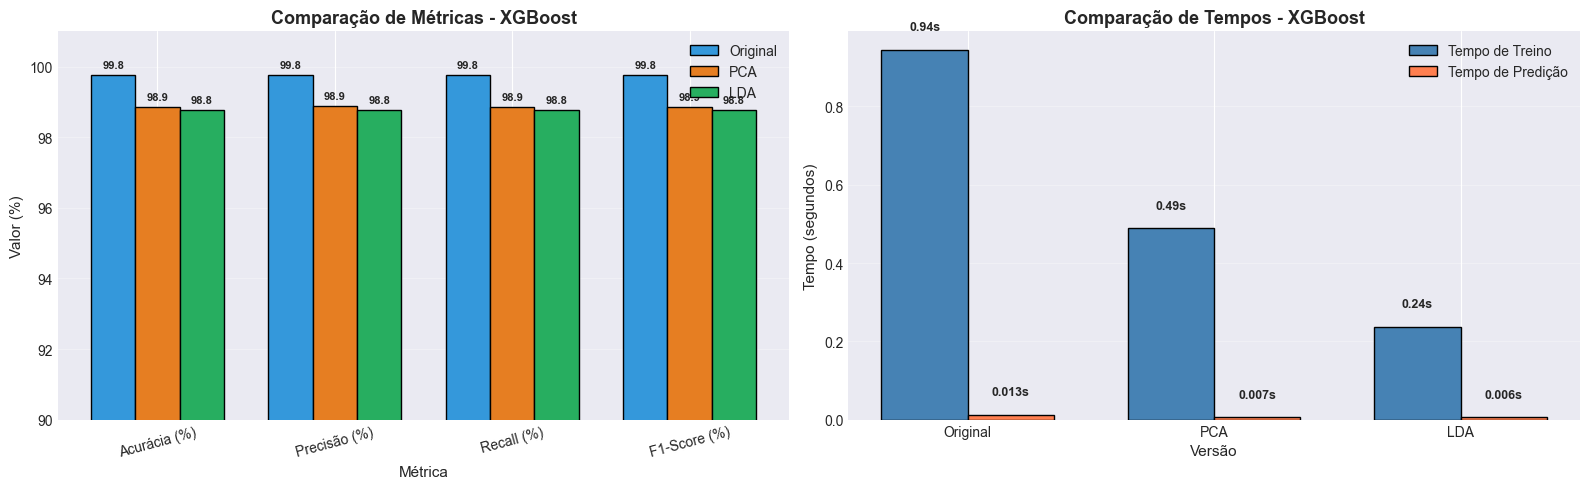

In [8]:
# visualização comparativa em gráfico de barras
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# gráfico fas métricas de classificação
metricas = ['Acurácia (%)', 'Precisão (%)', 'Recall (%)', 'F1-Score (%)']
versoes = ['Original', 'PCA', 'LDA']
cores = ['#3498db', '#e67e22', '#27ae60']

x_pos = np.arange(len(metricas))
largura = 0.25

for i, versao in enumerate(versoes):
    valores = [df_comparacao.loc[df_comparacao['Versão'] == versao, m].values[0] for m in metricas]
    axes[0].bar(x_pos + i*largura, valores, largura, label=versao, color=cores[i], edgecolor='black')

axes[0].set_xlabel('Métrica', fontsize=11)
axes[0].set_ylabel('Valor (%)', fontsize=11)
axes[0].set_title('Comparação de Métricas - XGBoost', fontsize=13, fontweight='bold')
axes[0].set_xticks(x_pos + largura)
axes[0].set_xticklabels(metricas, rotation=15)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([min(df_comparacao[metricas].values.min() - 2, 90), 101])

# adicionando valores nas barras
for i, versao in enumerate(versoes):
    valores = [df_comparacao.loc[df_comparacao['Versão'] == versao, m].values[0] for m in metricas]
    for j, v in enumerate(valores):
        axes[0].text(x_pos[j] + i*largura, v + 0.2, f'{v:.1f}', 
                     ha='center', fontsize=8, fontweight='bold')

# gráfico dos tempos de execução
tempos_treino = df_comparacao['Tempo Treino (s)'].values
tempos_pred = df_comparacao['Tempo Pred. (s)'].values

x_pos2 = np.arange(len(versoes))
largura2 = 0.35

axes[1].bar(x_pos2 - largura2/2, tempos_treino, largura2, 
            label='Tempo de Treino', color='steelblue', edgecolor='black')
axes[1].bar(x_pos2 + largura2/2, tempos_pred, largura2, 
            label='Tempo de Predição', color='coral', edgecolor='black')

axes[1].set_xlabel('Versão', fontsize=11)
axes[1].set_ylabel('Tempo (segundos)', fontsize=11)
axes[1].set_title('Comparação de Tempos - XGBoost', fontsize=13, fontweight='bold')
axes[1].set_xticks(x_pos2)
axes[1].set_xticklabels(versoes)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

# adicionando valores
for i, (t, p) in enumerate(zip(tempos_treino, tempos_pred)):
    axes[1].text(i - largura2/2, t + 0.05, f'{t:.2f}s', ha='center', fontweight='bold', fontsize=9)
    axes[1].text(i + largura2/2, p + 0.05, f'{p:.3f}s', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


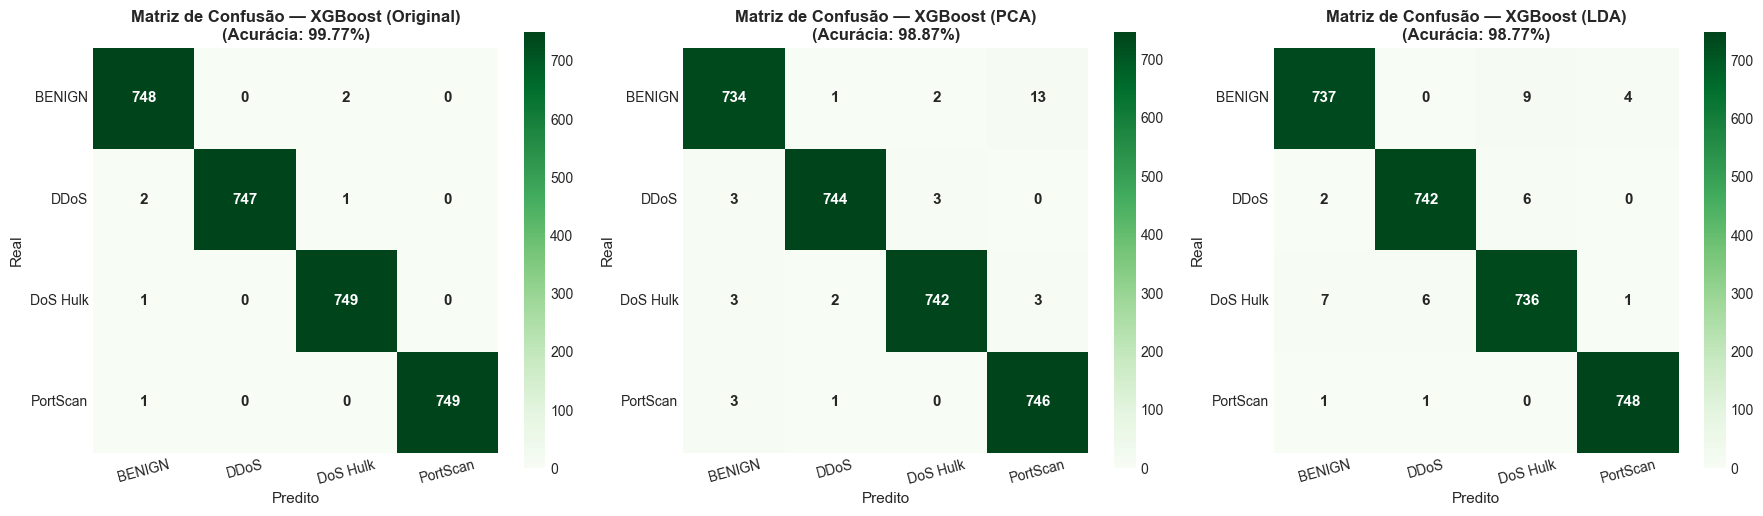

In [9]:
# mostrando as 3 matrizes de confusão lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

nomes_classes = list(codificador.classes_)

for idx, (versao, dados) in enumerate(resultados.items()):
    cm = confusion_matrix(y_test, dados['y_pred'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
                xticklabels=nomes_classes, yticklabels=nomes_classes,
                ax=axes[idx], cbar=True, square=True,
                annot_kws={'fontsize': 11, 'fontweight': 'bold'})
    
    axes[idx].set_xlabel('Predito', fontsize=11)
    axes[idx].set_ylabel('Real', fontsize=11)
    axes[idx].set_title(f'Matriz de Confusão — XGBoost ({versao})\n(Acurácia: {dados["acuracia"]*100:.2f}%)',
                        fontsize=12, fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=15)
    axes[idx].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


In [10]:
# mostrando o relatório de classificação completo para cada versão
nomes_classes = list(codificador.classes_)

for versao, dados in resultados.items():
    print(f"\n{'='*65}")
    print(f"Relatório de Classificação — XGBoost ({versao})")
    print(f"{'='*65}")
    print(classification_report(
        y_test, dados['y_pred'],
        target_names=nomes_classes,
        digits=4
    ))



Relatório de Classificação — XGBoost (Original)
              precision    recall  f1-score   support

      BENIGN     0.9947    0.9973    0.9960       750
        DDoS     1.0000    0.9960    0.9980       750
    DoS Hulk     0.9960    0.9987    0.9973       750
    PortScan     1.0000    0.9987    0.9993       750

    accuracy                         0.9977      3000
   macro avg     0.9977    0.9977    0.9977      3000
weighted avg     0.9977    0.9977    0.9977      3000


Relatório de Classificação — XGBoost (PCA)
              precision    recall  f1-score   support

      BENIGN     0.9879    0.9787    0.9833       750
        DDoS     0.9947    0.9920    0.9933       750
    DoS Hulk     0.9933    0.9893    0.9913       750
    PortScan     0.9790    0.9947    0.9868       750

    accuracy                         0.9887      3000
   macro avg     0.9887    0.9887    0.9887      3000
weighted avg     0.9887    0.9887    0.9887      3000


Relatório de Classificação — XGBoost

🔍 Top 15 Features Mais Importantes — XGBoost (Versão Original)



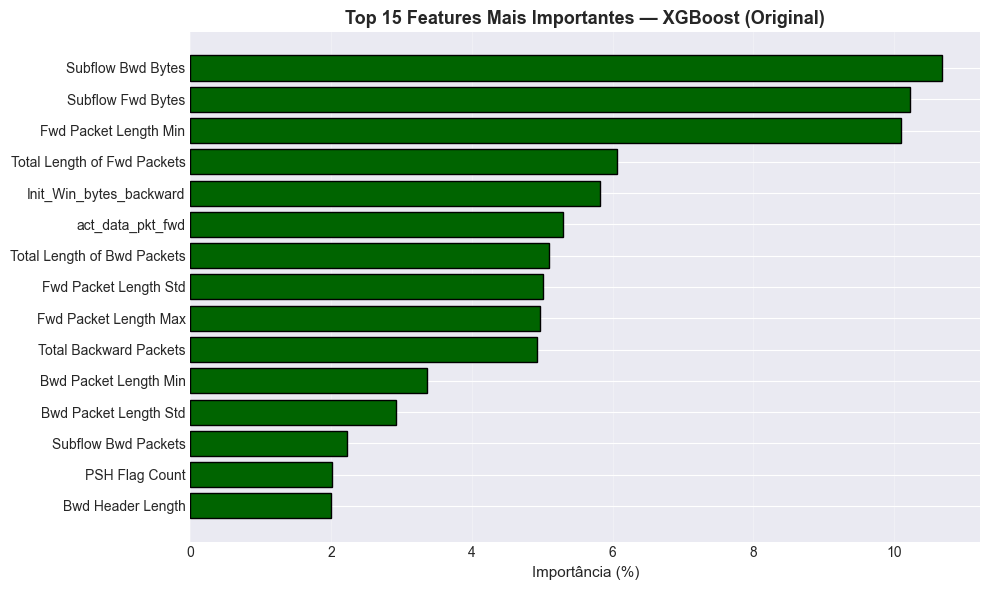

                    Feature  Importância
          Subflow Bwd Bytes     0.106871
          Subflow Fwd Bytes     0.102305
      Fwd Packet Length Min     0.100935
Total Length of Fwd Packets     0.060563
    Init_Win_bytes_backward     0.058218
           act_data_pkt_fwd     0.052903
Total Length of Bwd Packets     0.050928
      Fwd Packet Length Std     0.050072
      Fwd Packet Length Max     0.049703
     Total Backward Packets     0.049207
      Bwd Packet Length Min     0.033589
      Bwd Packet Length Std     0.029194
        Subflow Bwd Packets     0.022211
             PSH Flag Count     0.020044
          Bwd Header Length     0.020020


In [11]:
# análise de importância das features para a versão Original
# o XGBoost tambem mostra a importancia das features que nem o random forest

print("🔍 Top 15 Features Mais Importantes — XGBoost (Versão Original)\n")

modelo_original = resultados['Original']['modelo']
importancias = modelo_original.feature_importances_
nomes_features = X_train_orig.columns

# criando dataframe com importacias
df_importancia = pd.DataFrame({
    'Feature': nomes_features,
    'Importância': importancias
}).sort_values('Importância', ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(df_importancia['Feature'][::-1], df_importancia['Importância'][::-1] * 100, 
         color='darkgreen', edgecolor='black')
plt.xlabel('Importância (%)', fontsize=11)
plt.title('Top 15 Features Mais Importantes — XGBoost (Original)', 
          fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# tabela
print(df_importancia.to_string(index=False))


In [12]:
# salvando os 3 modelos treinados e as métricas
print("Salvando modelos e métricas\n")

# caminhos para salvar os modelos
caminhos_modelos = {
    'Original': os.path.join(pasta_modelos, 'modelo_xgb_original.pkl'),
    'PCA': os.path.join(pasta_modelos, 'modelo_xgb_pca.pkl'),
    'LDA': os.path.join(pasta_modelos, 'modelo_xgb_lda.pkl')
}

# salvando cada modelo
for versao, caminho in caminhos_modelos.items():
    joblib.dump(resultados[versao]['modelo'], caminho)
    tamanho_mb = os.path.getsize(caminho) / (1024 * 1024)
    print(f" Modelo XGBoost {versao}: {caminho} ({tamanho_mb:.2f} MB)")

# salvando métricas em CSV
pasta_resultados = '../resultados/metricas/'
os.makedirs(pasta_resultados, exist_ok=True)

caminho_metricas = os.path.join(pasta_resultados, 'metricas_xgboost.csv')
df_comparacao.to_csv(caminho_metricas, index=False)
print(f"\n  Métricas salvas: {caminho_metricas}")



Salvando modelos e métricas

 Modelo XGBoost Original: ../modelos/modelo_xgb_original.pkl (0.51 MB)
 Modelo XGBoost PCA: ../modelos/modelo_xgb_pca.pkl (0.78 MB)
 Modelo XGBoost LDA: ../modelos/modelo_xgb_lda.pkl (0.72 MB)

  Métricas salvas: ../resultados/metricas/metricas_xgboost.csv


In [13]:
# resumo final
print("\n" + "="*65)
print("RESUMO FINAL ")
print("="*65)

print(f"\nModelos treinados: 3 (Original, PCA, LDA)")
print(f"\nRanking XGBoost por F1-Score:")
ranking = df_comparacao.sort_values('F1-Score (%)', ascending=False)
for i, (_, row) in enumerate(ranking.iterrows(), 1):
    print(f"   {i}º — {row['Versão']:<10} F1: {row['F1-Score (%)']:.2f}%  |  Acc: {row['Acurácia (%)']:.2f}%")

print(f"\nEficiência:")
mais_rapido_treino = df_comparacao.loc[df_comparacao['Tempo Treino (s)'].idxmin(), 'Versão']
mais_rapido_pred = df_comparacao.loc[df_comparacao['Tempo Pred. (s)'].idxmin(), 'Versão']
print(f" Treinamento mais rápido:  {mais_rapido_treino}")
print(f" Predição mais rápida:     {mais_rapido_pred}")





RESUMO FINAL 

Modelos treinados: 3 (Original, PCA, LDA)

Ranking XGBoost por F1-Score:
   1º — Original   F1: 99.77%  |  Acc: 99.77%
   2º — PCA        F1: 98.87%  |  Acc: 98.87%
   3º — LDA        F1: 98.77%  |  Acc: 98.77%

Eficiência:
 Treinamento mais rápido:  LDA
 Predição mais rápida:     LDA
